In [4]:
import json
import glob
import os
import matplotlib.pyplot as plt

In [11]:
# evaluate results
offline_evals=[r"logs\2024-08-06-09-16-59-REVIEW46",r"logs\2024-08-06-09-22-19-REVIEW37",r"logs\2024-08-06-09-26-23-REVIEW35"]
raw_log_dir = r"logs\2024-08-06-online-118"
task_res={}
cnt_res={}
step_cnts = {"yes":{},"no":{},"unsure":{}}

for log_dir in offline_evals:
    for eval_dir in glob.glob(log_dir+"/*"):
        try:
            eval_json = json.load(open(os.path.join(eval_dir,"evaluation.log")))
            complete = eval_json.get("complete")
        except:
            continue
        # print(eval_dir)
        # locate the ori log
        response_log = os.path.join(raw_log_dir,os.path.basename(eval_dir),"response.log")
        steps = len(open(response_log,'r').readlines()) - 1
        if steps==0:
            complete="no"
        cnt_res[complete] = cnt_res.get(complete,0) + 1
        task_res[os.path.basename(eval_dir)] = complete
        step_cnts[complete][str(steps)] = step_cnts[complete].get(str(steps),0) + 1
        

print(f"Total tasks: {len(task_res.keys())}")
print(task_res)
print(f"Res Cnts:")
print(cnt_res)
print(f"Success Rate:")
print(cnt_res["yes"] / sum(cnt_res.values()))
print(f"Steps Distribution:")
print(step_cnts)

Total tasks: 118
{'0': 'yes', '1': 'no', '10': 'yes', '100': 'no', '101': 'no', '102': 'no', '103': 'no', '104': 'no', '105': 'yes', '106': 'yes', '107': 'no', '108': 'no', '109': 'no', '11': 'yes', '110': 'yes', '111': 'yes', '112': 'yes', '113': 'no', '114': 'yes', '115': 'yes', '116': 'no', '117': 'yes', '118': 'yes', '119': 'no', '12': 'no', '120': 'yes', '121': 'no', '122': 'unsure', '123': 'no', '124': 'no', '13': 'yes', '14': 'no', '15': 'unsure', '16': 'yes', '17': 'yes', '18': 'no', '19': 'no', '2': 'yes', '20': 'yes', '21': 'yes', '22': 'yes', '23': 'no', '24': 'no', '25': 'yes', '26': 'yes', '27': 'yes', '28': 'yes', '29': 'yes', '30': 'no', '31': 'no', '32': 'yes', '33': 'unsure', '34': 'yes', '35': 'yes', '36': 'yes', '37': 'yes', '38': 'no', '39': 'yes', '40': 'yes', '41': 'yes', '42': 'yes', '43': 'no', '44': 'yes', '45': 'yes', '46': 'no', '47': 'yes', '48': 'yes', '49': 'no', '50': 'no', '51': 'no', '52': 'no', '53': 'no', '54': 'yes', '55': 'yes', '56': 'yes', '57': '

In [16]:


def plot(cnts:dict=None,title:str="",keys:list=None,xlabel:str="",ylabel:str=""):
    if cnts:
        if keys:
            values = [cnts[k] for k in keys]
        else:
            keys = list(cnts.keys())
            values = list(cnts.values())
    try:
        keys, values = zip(*sorted(zip(keys, values), key=lambda x: int(x[0])))
    except Exception as e:
        pass
    # Plotting the histogram with values on the bars
    plt.figure(figsize=(30, 3))
    bars = plt.bar(keys, values, color='skyblue', edgecolor='black')

    # Adding value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, height, str(height), ha='center', va='bottom')

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(keys)  # Ensure all keys are shown on the x-axis
    plt.grid(axis='y')

    # Show the plot
    plt.show()

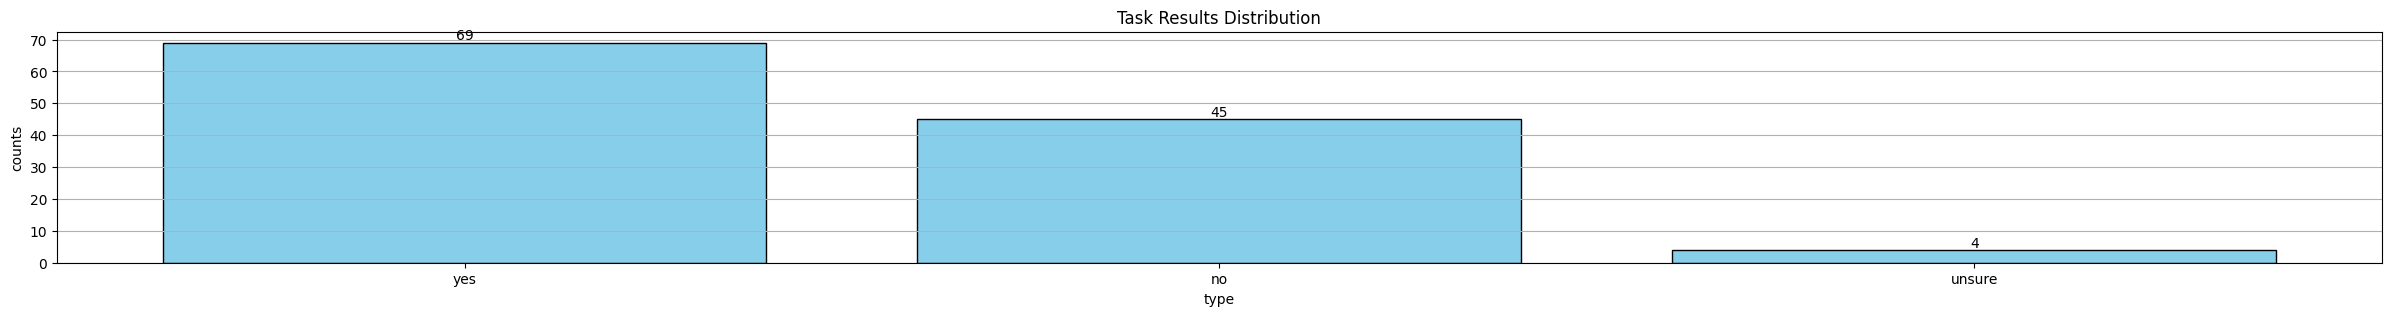

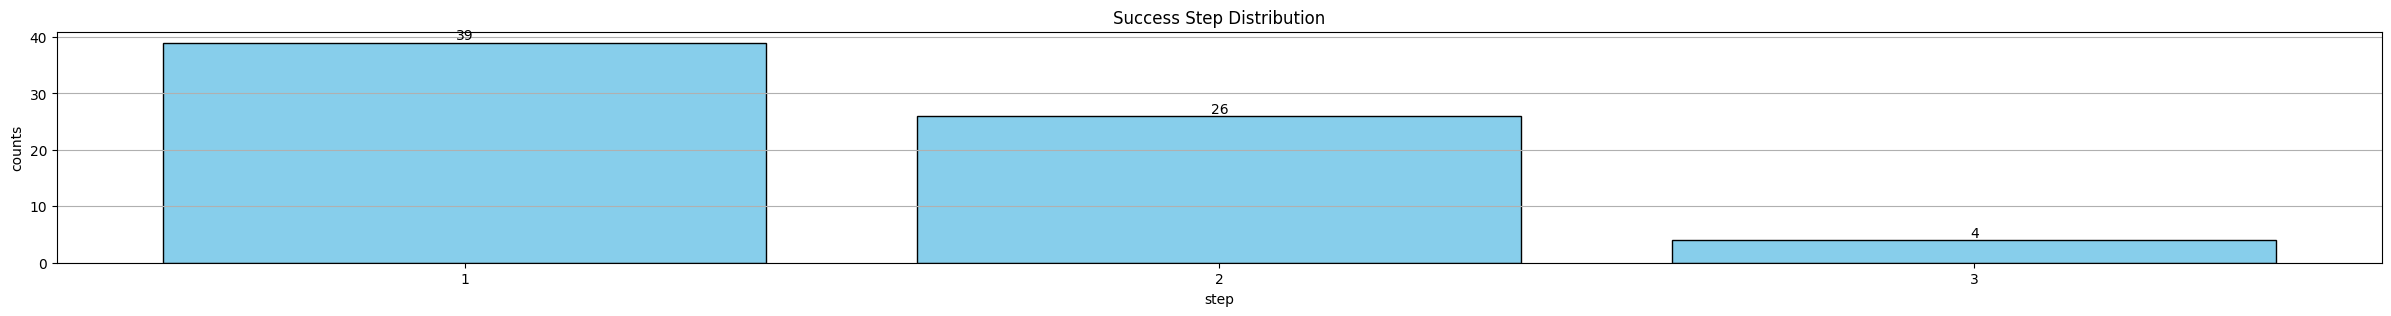

In [17]:
res_cnts={'yes': 69, 'no': 45, 'unsure': 4}
step_cnts ={'3': 4, '1': 39, '2': 26}

plot(res_cnts,title="Task Results Distribution",xlabel="type",ylabel="counts",keys=["yes","no","unsure"])
plot(step_cnts,title="Success Step Distribution",xlabel="step",ylabel="counts")


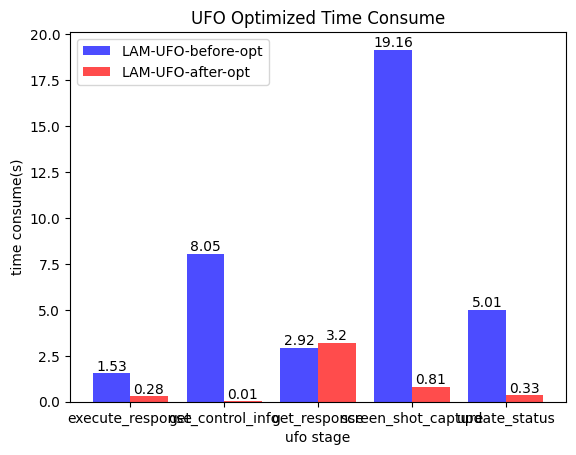

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
x = np.arange(5)
y2 = [0.27669358253479004, 0.0065415700276692705, 3.1952404181162515, 0.8065505822499593, 0.3333781560262044]
y1 = [1.53, 8.05, 2.92, 19.16, 5.01]

# 创建一个图表
fig, ax = plt.subplots()

# 第一个柱状图
bar_width = 0.4  # 设置柱状图的宽度
bars1 = ax.bar(x - bar_width/2, y1, bar_width, label='LAM-UFO-before-opt', color='b', alpha=0.7)

# 第二个柱状图
bars2 = ax.bar(x + bar_width/2, y2, bar_width, label='LAM-UFO-after-opt', color='r', alpha=0.7)

# 添加标签和标题
ax.set_xlabel('ufo stage')
ax.set_ylabel('time consume(s)')
ax.set_title('UFO Optimized Time Consume')
ax.set_xticks(x)
ax.set_xticklabels(['execute_response', 'get_control_info', 'get_response', 'screen_shot_capture', 'update_status'])
ax.legend()

# 在每个柱子上显示数值
for bar in bars1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

# 显示图表
plt.show()


In [4]:
import json
import shutil
import glob
import os
# copy test samples to repair
passed_tasks = open("passed.txt",'r').readlines()
tasks={}
for pt in passed_tasks:
    tasks[pt] = 1 
# prefilled tasks
prefilled_tasks = glob.glob(r"D:\agents\AgentLearner\prefill_logs\*")
for task in prefilled_tasks:
    task_name = os.path.basename(task)
    if task_name not in tasks:
        shutil.copyfile(r"D:\agents\AgentLearner\tasks\action_prefill"+rf"\{task_name}.json", r"D:\agents\UFO\sample\tasks"+rf"\{task_name}.json")

In [21]:
# repair results
import json
import glob
import os
raw_log_dirs = [r"D:\agents\UFO\logs\2024-10-31-15-45-49"]
raw_task_dir = r"D:\agents\UFO\sample\repair_samples_1\repair_samples_5\tasks"
task_res={}
cnt_res={}
step_cnts = {"yes":{},"no":{},"unsure":{}}
tmps = []
tasks = []
non_tasks = []
for raw_log_dir in raw_log_dirs:
    print(raw_log_dir)
    task_dirs = glob.glob(raw_log_dir+"/*")
    for eval_dir in task_dirs:
        tmp = {}
        task = {}
        try:
            eval_json = json.load(open(os.path.join(eval_dir,"evaluation.log"),'r'))
            # problem_json = json.load(open(os.path.join(raw_task_dir,os.path.basename(eval_dir)+".json"),'r'))
            
            complete = eval_json.get("complete")
        except Exception as e:
            # print(e)
            non_tasks.append(eval_dir)
            continue
        # locate the ori log
        task['task_id'] = os.path.basename(eval_dir)
        # task['problem'] = problem_json.get('new_problem')
        # task['rid'] = problem_json.get('rid')
        # print(problem_json.get('rid'))
        task['result'] = complete
        # print(response_json.keys())
        
        response_log = os.path.join(eval_dir,"response.log")

            

        steps = len(open(response_log,'r').readlines())
        request_steps = len(open(os.path.join(eval_dir,"request.log"),'r').readlines())
        task_step = []
        if steps<=1 or request_steps!= steps:
            complete="no"
            task['result'] = complete
        else:
            for i in range(1,steps):
                # if i != 0:
                step = {}
                request_json = json.loads(open(os.path.join(eval_dir,"request.log"),'r').readlines()[i])
                response_json = json.loads(open(os.path.join(eval_dir,"response.log"),'r').readlines()[i])

                # print(request_json.keys())
                step['id'] = str(i)
                # print(request_json['prompt'][1]['content'])
                step['request'] = request_json
                # print(response_json.keys())
                step['response'] = response_json
                    # {'status':response_json['status'],'plan':response_json['plan'], 'request':response_json['Request'], 'thought':response_json['thought'],
                                # 'control_label':response_json['control_label'], 'control_name':response_json['control_name'],
                                # 'function' :response_json['function'], 'args':response_json['args']    }
                # if response_json['status'] != 'ERROR':
                #     print(response_json)
                #     assert 0
                task_step.append(step)
        # task['steps'] = task_step
        # tasks.append(task)



        # if steps > 2 and complete == 'yes':
        #     # print(response_log)
        # #    file = json.loads(open(os.path.join(task_path, response_log.split(raw_log_dir)[1].strip('\\').split('\\')[0])+'.json','r').read())
        # #    print(file.get("new_problem"))
        #     name = response_log.split(raw_log_dir)[1].strip('\\').split('\\')[0]
        #     move_file(name)
        # print(task)
        # cnt_res[complete] = cnt_res.get(complete,0) + 1
        # task_res[os.path.basename(eval_dir)] = complete
        # step_cnts[complete][str(steps)] = step_cnts[complete].get(str(steps),0) + 1


        if complete == 'no':
            tmp['task_id'] = os.path.basename(eval_dir)
            tmp['steps'] = task_step
            tmps.append(tmp)

        # assert 0

# print(f"Total tasks: {len(task_res.keys())}")
# print(task_res)
# print(f"Res Cnts:")
# print(cnt_res)
# print(f"Success Rate:")
# print(cnt_res["yes"] / sum(cnt_res.values()))
# print(f"Steps Distribution:")
# print(step_cnts)
json.dump(tmps, open('boost_fail.json','w'))



logs\0+7
logs\1+7
logs\2+7
logs\3+7
logs\4+7
logs\5+7
logs\6+7


In [11]:
# repair results
import json
import glob
import os
raw_log_dirs = [r"D:\agents\UFO\logs\2024-10-31-15-45-49"]
raw_task_dir = r"D:\agents\UFO\sample\repair_samples_1\repair_samples_5\tasks"
task_res={}
cnt_res={}
step_cnts = {"yes":{},"no":{},"unsure":{}}
tmps = []
tasks = []
non_tasks = []
for raw_log_dir in raw_log_dirs:
    print(raw_log_dir)
    task_dirs = glob.glob(raw_log_dir+"/*")
    for eval_dir in task_dirs:
        tmp = {}
        task = {}
        try:
            eval_json = json.load(open(os.path.join(eval_dir,"evaluation.log"),'r'))
            # problem_json = json.load(open(os.path.join(raw_task_dir,os.path.basename(eval_dir)+".json"),'r'))
            
            complete = eval_json.get("complete")
        except Exception as e:
            # print(e)
            non_tasks.append(eval_dir)
            continue
        # locate the ori log
        task['task_id'] = os.path.basename(eval_dir)
        # task['problem'] = problem_json.get('new_problem')
        # task['rid'] = problem_json.get('rid')
        # print(problem_json.get('rid'))
        task['result'] = complete
        # print(response_json.keys())
        
        response_log = os.path.join(eval_dir,"response.log")

            

        steps = len(open(response_log,'r').readlines())
        request_steps = len(open(os.path.join(eval_dir,"request.log"),'r').readlines())
        task_step = []
        if steps<=1 or request_steps!= steps:
            complete="no"
            task['result'] = complete
        else:
            for i in range(1,steps):
                # if i != 0:
                step = {}
                request_json = json.loads(open(os.path.join(eval_dir,"request.log"),'r').readlines()[i])
                response_json = json.loads(open(os.path.join(eval_dir,"response.log"),'r').readlines()[i])

                # print(request_json.keys())
                step['id'] = str(i)
                # print(request_json['prompt'][1]['content'])
                step['request'] = request_json
                # print(response_json.keys())
                step['response'] = response_json
                    # {'status':response_json['status'],'plan':response_json['plan'], 'request':response_json['Request'], 'thought':response_json['thought'],
                                # 'control_label':response_json['control_label'], 'control_name':response_json['control_name'],
                                # 'function' :response_json['function'], 'args':response_json['args']    }
                # if response_json['status'] != 'ERROR':
                #     print(response_json)
                #     assert 0
                task_step.append(step)
        # task['steps'] = task_step
        tasks.append(task)



        # if steps > 2 and complete == 'yes':
        #     # print(response_log)
        # #    file = json.loads(open(os.path.join(task_path, response_log.split(raw_log_dir)[1].strip('\\').split('\\')[0])+'.json','r').read())
        # #    print(file.get("new_problem"))
        #     name = response_log.split(raw_log_dir)[1].strip('\\').split('\\')[0]
        #     move_file(name)
        # print(tasks)
        # cnt_res[complete] = cnt_res.get(complete,0) + 1
        # task_res[os.path.basename(eval_dir)] = complete
        # step_cnts[complete][str(steps)] = step_cnts[complete].get(str(steps),0) + 1


        # if complete == 'no':
        #     tmp['task_id'] = os.path.basename(eval_dir)
        #     tmp['steps'] = task_step
        #     tmps.append(tmp)

        # assert 0

# print(f"Total tasks: {len(task_res.keys())}")
# print(task_res)
# print(f"Res Cnts:")
# print(cnt_res)
# print(f"Success Rate:")
# print(cnt_res["yes"] / sum(cnt_res.values()))
# print(f"Steps Distribution:")
# print(step_cnts)
# json.dump(tmps, open('boost_fail.json','w'))



D:\agents\UFO\logs\2024-10-31-15-45-49


In [13]:
yes = []
no = []
unsure = []
for task in tasks:
    if task['result'] == 'yes':
        yes.append(task['result'])
    elif task['result'] == 'no':
        no.append(task['result'])
    elif task['result'] == 'unsure':
        unsure.append(task['result'])

In [16]:
print(len(no))
print(len(unsure))
print(len(yes))

81
6
103


In [2]:
# repair results
import json
import glob
import os
raw_log_dir = r"logs\2024-08-21-05-43-23"
raw_task_dir = r"C:\Users\ufo\Desktop\sample_2\sample_2\tasks"
task_res={}
cnt_res={}
step_cnts = {"yes":{},"no":{},"unsure":{}}
task_dirs = glob.glob(raw_log_dir+"/*")
tasks = []
non_tasks = []
for eval_dir in task_dirs:
    task = {}
    try:
        eval_json = json.load(open(os.path.join(eval_dir,"evaluation.log"),'r'))
        problem_json = json.load(open(os.path.join(raw_task_dir,os.path.basename(eval_dir)+".json"),'r'))
        
        complete = eval_json.get("complete")
    except Exception as e:
        non_tasks.append(eval_dir)
        continue
    # locate the ori log
    # task['task_id'] = os.path.basename(eval_dir)
    # task['problem'] = problem_json.get('new_problem')
    task['rid'] = problem_json.get('rid')
    # print(problem_json.get('rid'))
    task['result'] = complete
    # print(response_json.keys())
    
    # response_log = os.path.join(eval_dir,"response.log")

        

    # steps = len(open(response_log,'r').readlines())
    # request_steps = len(open(os.path.join(eval_dir,"request.log"),'r').readlines())
    # task_step = []
    # if steps<=1 or request_steps!= steps:
    #     complete="no"
    #     task['result'] = complete
    # else:
    #     for i in range(1,steps):
    #         # if i != 0:
    #         step = {}
    #         request_json = json.loads(open(os.path.join(eval_dir,"request.log"),'r').readlines()[i])
    #         response_json = json.loads(open(os.path.join(eval_dir,"response.log"),'r').readlines()[i])

    #         # print(request_json.keys())
    #         step['id'] = str(i)
    #         # print(request_json['prompt'][1]['content'])
    #         step['question'] = request_json['prompt'][0]['content']+request_json['prompt'][1]['content'][0]['text']
    #         # print(response_json.keys())
    #         step['response'] = response_json
    #             # {'status':response_json['status'],'plan':response_json['plan'], 'request':response_json['Request'], 'thought':response_json['thought'],
    #                         # 'control_label':response_json['control_label'], 'control_name':response_json['control_name'],
    #                         # 'function' :response_json['function'], 'args':response_json['args']    }
    #         # if response_json['status'] != 'ERROR':
    #         #     print(response_json)
    #         #     assert 0
    #         task_step.append(step)
    # task['steps'] = task_step
    # tasks.append(task)



    # if steps > 2 and complete == 'yes':
    #     # print(response_log)
    # #    file = json.loads(open(os.path.join(task_path, response_log.split(raw_log_dir)[1].strip('\\').split('\\')[0])+'.json','r').read())
    # #    print(file.get("new_problem"))
    #     name = response_log.split(raw_log_dir)[1].strip('\\').split('\\')[0]
#     #     move_file(name)
#     # print(task)
#     cnt_res[complete] = cnt_res.get(complete,0) + 1
    # task_res[problem_json.get('rid')] = complete
    task_res[os.path.basename(eval_dir)] = problem_json.get('rid')
#     step_cnts[complete][str(steps)] = step_cnts[complete].get(str(steps),0) + 1
#     # assert 0

# print(f"Total tasks: {len(task_res.keys())}")
print(len(task_res))
# print(f"Res Cnts:")
# print(cnt_res)
# print(f"Success Rate:")
# print(cnt_res["yes"] / sum(cnt_res.values()))
# print(f"Steps Distribution:")
# print(step_cnts)



348


In [4]:
from distutils.dir_util import copy_tree
unsure = []
falses = []
trues = []

for key, value in task.items():

    if value =='unsure':
        unsure.append(key)
    elif value == 'no':
        falses.append(key)
    elif value == 'yes':
        trues.append(key)
# print(len(falses))
# raw_log_dir = r"logs\2024-09-10-04-22-09"
# # dir = r"logs\unsure"
# # os.makedirs(dir, exist_ok=True)
# # for _ in unsure:
# #     copy_tree(os.path.join(raw_log_dir, _), os.path.join(dir, _))
# # dir = r"logs\negative"
# # os.makedirs(dir, exist_ok=True)
# # for _ in falses:
# #     copy_tree(os.path.join(raw_log_dir, _), os.path.join(dir, _))
# dir = r"logs\positive"
# os.makedirs(dir, exist_ok=True)
# for _ in trues:
#     copy_tree(os.path.join(raw_log_dir, _), os.path.join(dir, _))
# for _ in unsure:
#     print(_)
# for _ in trues:
#     print(_)
# for _ in falses:
#     print(_)


95
no


In [3]:
json.dump(tasks, open('new_new_eval.json','w'))

In [116]:
# for task in non_tasks:
#     print(os.path.basename(task))
# print(non_tasks)
path = r"D:\agents\UFO\sample\testset_pending\tasks"
files = os.listdir(path)
# for file in files:
nums = 0
non_tasks_name = [os.path.basename(non_task) for non_task in non_tasks]
# print(len(non_tasks))
# print(len(files)-348)
for file in files:
    if file.split('.')[0] not in non_tasks_name:
        os.remove(path+'\\\\'+file)
        


In [79]:
print(response_json['plan'])
print(response_json['thought'])
print(response_json['control_label'])
print(response_json['control_name'])
print(response_json['function'])
print(response_json['args'])
print(response_json['Request'])


["Click on the 'Paragraph...' button to open paragraph settings dialog"]
Click on the 'Home' tab to access paragraph settings
24
Home
click_input
{'button': 'left', 'double': False}
Guide the user to open the 'Paragraph' settings under the 'Home' tab to adjust indentation to 'Hanging'.


In [68]:
print(len(tasks))

348


In [11]:
import os
import shutil

# 定义原始目录和目标目录
scr_dic = r"D:\\agents\\UFO\\sample\\testset_20240820\\"
src_dir_tasks = 'tasks'
src_dir_files = 'files'
dir = r"D:\\agents\\UFO\\sample\\new_samples\\"
dir_tasks = 'tasks'
dir_files = 'files'


# 创建目标目录，如果它不存在的话
os.makedirs(dir, exist_ok=True)
os.makedirs(dir+dir_files, exist_ok=True)
os.makedirs(dir+dir_tasks, exist_ok=True)

def move_file(name):
# 构建源文件和目标文件的完整路径
    src_file_json = os.path.join(scr_dic+src_dir_tasks, f'{name}.json')
    src_file_docx = os.path.join(scr_dic+src_dir_files, f'{name}.docx')
    dst_file_json = os.path.join(dir+dir_tasks, f'{name}.json')
    dst_file_docx = os.path.join(dir+dir_files, f'{name}.docx')

    # 复制文件
    try:
        shutil.copy(src_file_json, dst_file_json)
        shutil.copy(src_file_docx, dst_file_docx)
        print("文件复制成功！")
    except Exception as e:
        print(f"复制过程中发生错误：{e}")


In [1]:
import shutil
import os

subfolders = ['104', '105', '107', '110', '114', '120', '124', '128', '131', '137', '14', '140', '143', '144', '145', '146', '147', '149', '15', '150', '152', '153', '154', '155', '156', '157', '158', '159', '16', '160', '161', '162', '163', '164', '165', '166', '167', '169', '17', '170', '171', '173', '174', '175', '176', '177', '180', '181', '182', '183', '186', '188', '190', '194', '195', '196', '197', '2', '20', '200', '201', '202', '203', '204', '205', '206', '207', '208', '209', '21', '210', '212', '213', '214', '215', '216', '217', '218', '219', '220', '221', '222', '224', '225', '226', '227', '228', '230', '231', '232', '233', '234', '235', '236', '237', '238', '239', '24', '240', '241', '242', '243', '244', '245', '246', '247', '248', '249', '250', '251', '253', '254', '257', '258', '259', '26', '262', '263', '264', '265', '266', '267', '268', '269', '27', '270', '271', '272', '275', '276', '278', '279', '282', '285', '289', '290', '291', '292', '295', '298', '303', '304', '31', '310', '317', '32', '321', '322', '324', '327', '329', '335', '34', '342', '35', '352', '356', '358', '359', '36', '363', '365', '370', '379', '382', '383', '385', '396', '398', '4', '401', '410', '412', '414', '418', '419', '42', '420', '44', '47', '49', '5', '51', '53', '55', '6', '63', '64', '67', '68', '7', '73', '76', '8', '91', '94', '95']


# 定义目标文件夹和新的目标文件夹
target_dir = r"D:\agents\UFO\sample\testset_20240820\tasks"
new_target_dir = r"D:\agents\UFO\sample\testset_pending\testset_pending\tasks"

# 创建新的目标文件夹（如果不存在）
os.makedirs(new_target_dir, exist_ok=True)

# 遍历 subfolders 列表并移动相应的文件
for number in subfolders:
    file_name = f"{number}.json"
    source_file = os.path.join(target_dir, file_name)
    if os.path.exists(source_file):
        shutil.move(source_file, new_target_dir)